# 02 · Roll calendar validation

Volume-crossover rolls with a two-session confirmation, built from the cleaned outright frame. Checks: counts against contract-month arithmetic, the months rolled into, timing relative to expiry, and the CL April 2020 episode.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from futures_lab.config import REPO_ROOT, ROLL_CONFIRM_DAYS, ROOTS
from futures_lab.data.contracts import parse_contract
from futures_lab.data.load import load_outrights
from futures_lab.data.rolls import daily_volume_leader, detect_rolls

bars = {root: load_outrights(root) for root in ROOTS}
leaders = {root: daily_volume_leader(df) for root, df in bars.items()}
rolls = {root: detect_rolls(leaders[root], root, ROLL_CONFIRM_DAYS) for root in ROOTS}

## Counts

Expected over 2016-01 to 2026-06 (10.5 years): quarterly roots 42, GC 52 (five active months), CL 126. Sessions per year land near 260 rather than 252: once Sunday stub bars are folded, what remains are the ~252 full sessions plus the abbreviated Globex sessions CME runs on most US holidays (MLK, Presidents', Memorial, Juneteenth, Independence, Labor, Thanksgiving). Those are real, low-volume sessions and are kept.

In [2]:
expected = {"ES": 42, "ZB": 42, "CL": 126, "GC": 52, "6E": 42}
pd.DataFrame(
    {
        "sessions": {r: len(leaders[r]) for r in ROOTS},
        "sessions per year": {r: round(len(leaders[r]) / 10.5) for r in ROOTS},
        "rolls": {r: len(rolls[r]) for r in ROOTS},
        "expected": expected,
    }
)

,sessions,sessions per year,rolls,expected
ES,2726,260,42,42
ZB,2725,260,42,42
CL,2722,259,126,126
GC,2722,259,53,52
6E,2726,260,42,42


In [3]:
rolls["ES"].head(8)

,roll_date,crossover_date,from_symbol,to_symbol,from_instrument_id,to_instrument_id
0,2016-03-14,2016-03-11,ESH6,ESM6,49705,6505
1,2016-06-13,2016-06-10,ESM6,ESU6,6505,2615
2,2016-09-12,2016-09-09,ESU6,ESZ6,2615,2928
3,2016-12-12,2016-12-09,ESZ6,ESH7,2928,35903
4,2017-03-13,2017-03-10,ESH7,ESM7,35903,9006
5,2017-06-12,2017-06-09,ESM7,ESU7,9006,24842
6,2017-09-11,2017-09-08,ESU7,ESZ7,24842,23936
7,2017-12-11,2017-12-08,ESZ7,ESH8,23936,21168


## Which months do we roll into?

GC should only land on G, J, M, Q, Z; the quarterly roots on H, M, U, Z; CL on every month.

In [4]:
pd.DataFrame({r: rolls[r]["to_symbol"].str[len(r)].value_counts() for r in ROOTS}).fillna(0).astype(int)

,ES,ZB,CL,GC,6E
to_symbol,,,,,
F,0,0,10,0,0
G,0,0,10,10,0
H,10,10,11,0,10
J,0,0,11,11,0
K,0,0,11,0,0
M,11,11,11,11,11
N,0,0,11,0,0
Q,0,0,11,11,0
U,11,11,10,0,11


## Timing relative to expiry (ES)

ES stops trading on the third Friday of the contract month. Volume crosses to the next contract on the Friday or Monday before expiry week (open interest moves earlier, on roll Thursday), and the two-session rule confirms one session later, so the confirmed roll should land on the Monday or Tuesday of expiry week: 3 or 4 calendar days before the third Friday.

In [5]:
def third_friday(year, month):
    first = pd.Timestamp(year=year, month=month, day=1)
    return first + pd.Timedelta(days=(4 - first.weekday()) % 7 + 14)

es_rolls = rolls["ES"].copy()
keys = [parse_contract(s, "ES", d) for s, d in zip(es_rolls["from_symbol"], es_rolls["roll_date"], strict=True)]
es_rolls["expiry"] = [third_friday(y, m) for y, m in keys]
es_rolls["days_before_expiry"] = (es_rolls["expiry"] - es_rolls["roll_date"]).dt.days
es_rolls["days_before_expiry"].value_counts().sort_index()

days_before_expiry
3    21
4    21
Name: count, dtype: int64

## Front-month close with roll dates (ES)

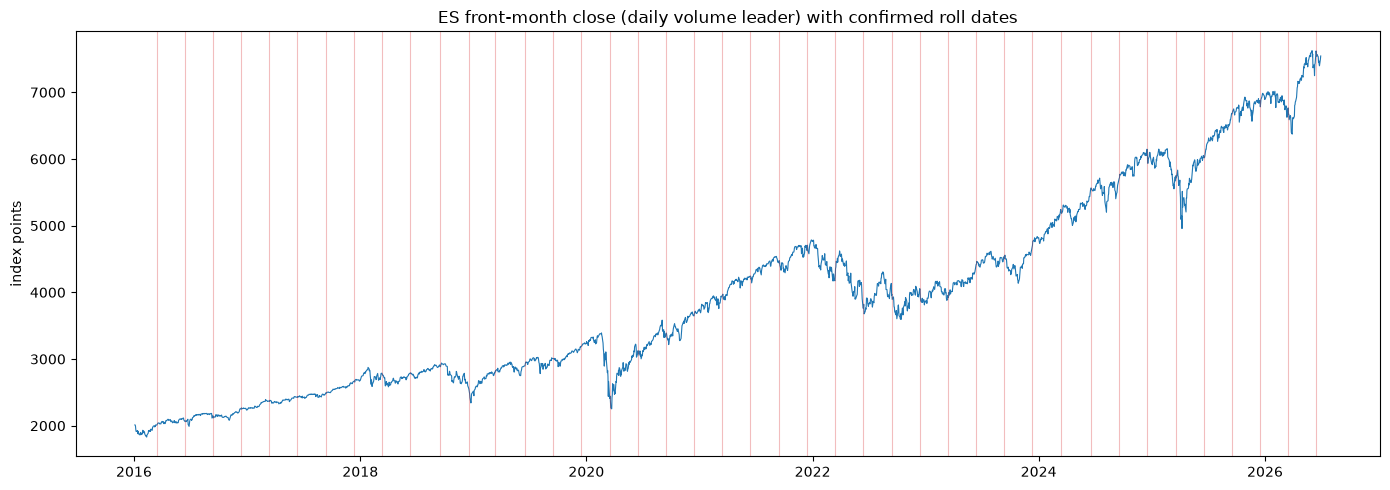

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
lead = leaders["ES"]
ax.plot(lead.index, lead["close"], lw=0.8)
for d in rolls["ES"]["roll_date"]:
    ax.axvline(d, color="tab:red", alpha=0.3, lw=0.8)
ax.set_title("ES front-month close (daily volume leader) with confirmed roll dates")
ax.set_ylabel("index points")
plt.tight_layout()
fig_dir = REPO_ROOT / "docs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "es_roll_dates.png", dpi=150)
plt.show()

## CL, April 2020

CLK0 settled at -37.63 on 2020-04-20 (the UTC bar closes at -2.67). Volume had moved to CLM0 on 2020-04-16, so the rule rolls on 2020-04-17 and the front-month series never holds the negative print. This matters for log returns downstream.

In [7]:
cl = bars["CL"].loc["2020-04-14":"2020-04-22"]
top_two = cl.sort_values("volume", ascending=False).groupby(level=0).head(2).sort_index()
top_two[["symbol", "close", "volume"]]

,symbol,close,volume
session,,,
2020-04-14,CLK0,20.87,516470
2020-04-14,CLM0,28.09,150090
2020-04-15,CLK0,20.31,428352
2020-04-15,CLM0,26.46,200339
2020-04-16,CLM0,26.51,269060
2020-04-16,CLK0,19.94,246219
2020-04-17,CLM0,25.14,465489
2020-04-17,CLK0,18.12,153263
2020-04-20,CLM0,21.27,980575


In [8]:
rolls["CL"][rolls["CL"]["roll_date"].between("2020-03-01", "2020-05-31")]

,roll_date,crossover_date,from_symbol,to_symbol,from_instrument_id,to_instrument_id
50,2020-03-19,2020-03-18,CLJ0,CLK0,496408,22770
51,2020-04-17,2020-04-16,CLK0,CLM0,22770,653814
52,2020-05-08,2020-05-07,CLM0,CLN0,653814,105602


In [9]:
print("minimum CL front-month close:", leaders["CL"]["close"].min())

minimum CL front-month close: 12.26
